Q1. Data Loading & Understanding
a) Load the dataset into Python.
b) Display the first 5 rows.
c) Check the shape of the dataset.
d) Display the data types of each column.

In [3]:
import pandas as pd

df = pd.read_excel('/content/loan_approval.xlsx')

# Display the first 5 rows
print(df.head())

# Check the shape of the dataset
print(df.shape)

# Display the data types of each column
print(df.dtypes)

              name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810           389        39698   
1     Brandon Hall     New Jamesside   44592           729        15446   
2     Rhonda Smith      Lake Roberto   33278           584        11189   
3  Gabrielle Davis  West Melanieview  127196           344        48823   
4     Valerie Gray         Mariastad   66048           496        47174   

   years_employed  points  loan_approved  
0              27      50          False  
1              28      55          False  
2              13      45          False  
3              29      50          False  
4               4      25          False  
(2000, 8)
name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object


Q2. Data Cleaning
a) Check for missing values in the dataset.
b) Handle missing values appropriately.
c) Identify categorical columns present in the dataset.

In [4]:
# Check for missing values in the dataset
print(df.isnull().sum())

# Handle missing values appropriately
df.dropna(inplace=True)

# Identify categorical columns present in the dataset
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64
Index(['name', 'city'], dtype='object')


Q3. Exploratory Data Analysis (EDA)
a) Plot the distribution of the target variable.
b) Analyze the relationship between one numerical feature and the target variable.
c) Analyze the relationship between Years of Employment and the target variable.

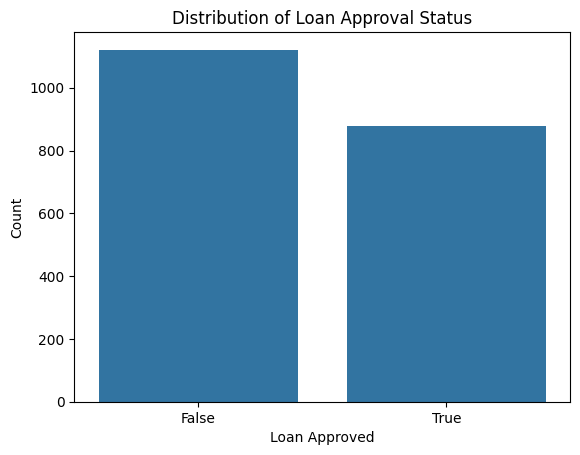

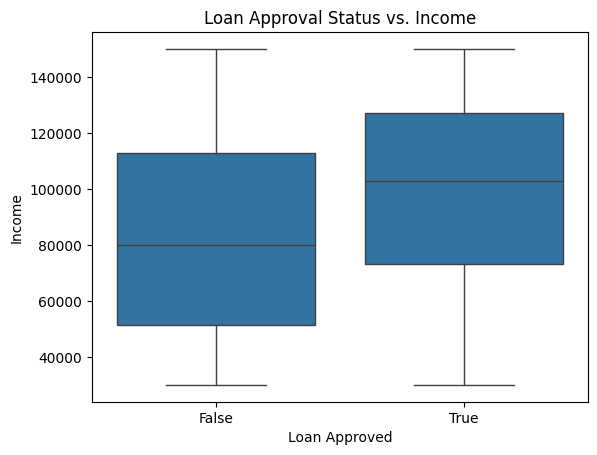

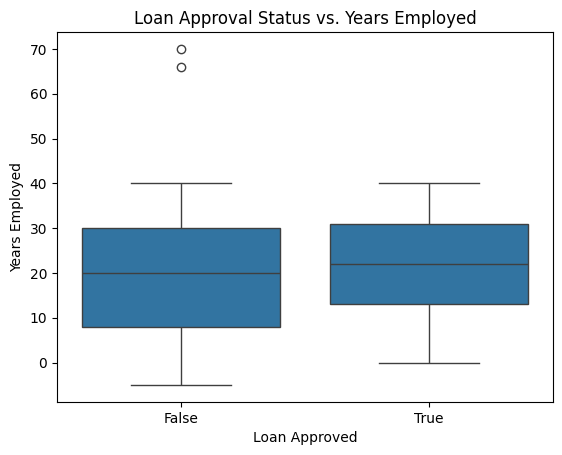

In [6]:
# Plot the distribution of the target variable.

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='loan_approved', data=df)
plt.title('Distribution of Loan Approval Status')
plt.xlabel('Loan Approved')
plt.ylabel('Count')
plt.show()

# Analyze the relationship between one numerical feature (income) and the target
sns.boxplot(x='loan_approved', y='income', data=df)
plt.title('Loan Approval Status vs. Income')
plt.xlabel('Loan Approved')
plt.ylabel('Income')
plt.show()

# Analyze the relationship between Years of Employment and the target variable.
sns.boxplot(x='loan_approved', y='years_employed', data=df)
plt.title('Loan Approval Status vs. Years Employed')
plt.xlabel('Loan Approved')
plt.ylabel('Years Employed')
plt.show()

Q4. Outlier Detection and Treatment
a) Detect outliers in numerical columns using the IQR method.
b) Treat outliers using capping techniques

In [9]:
# Detect outliers in numerical columns using the IQR method.
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
# Note: This 'outliers' variable will contain a boolean Series indicating rows with outliers in ANY numerical column.
outliers = ((df[numerical_cols] < (Q1 - 1.5 * IQR)) | (df[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
print("Number of rows with outliers: ", outliers.sum())

# Treat outliers using capping techniques
df_capped = df.copy()
for col in numerical_cols: # Iterate only over numerical columns
    Q1_col = df[col].quantile(0.25)
    Q3_col = df[col].quantile(0.75)
    IQR_col = Q3_col - Q1_col
    lower_bound = Q1_col - 1.5 * IQR_col
    upper_bound = Q3_col + 1.5 * IQR_col

    # Capping
    df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)

print("Original DataFrame head:")
print(df.head())
print("\nDataFrame after capping outliers head:")
print(df_capped.head())

Number of rows with outliers:  5
Original DataFrame head:
              name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810           389        39698   
1     Brandon Hall     New Jamesside   44592           729        15446   
2     Rhonda Smith      Lake Roberto   33278           584        11189   
3  Gabrielle Davis  West Melanieview  127196           344        48823   
4     Valerie Gray         Mariastad   66048           496        47174   

   years_employed  points  loan_approved  
0              27      50          False  
1              28      55          False  
2              13      45          False  
3              29      50          False  
4               4      25          False  

DataFrame after capping outliers head:
              name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810         389.0        39698   
1     Brandon Hall     New Jamesside   4459

Q5. Convert target variables into numerical format suitable for model building and drop unnecessary
columns.

In [11]:
# Convert the target variable 'loan_approved' to numerical format (0s and 1s)
df_model = df_capped.copy()
df_model['loan_approved'] = df_model['loan_approved'].astype(int)

# Drop unnecessary columns like 'name' and 'city'
df_model = df_model.drop(columns=['name', 'city'])

print("DataFrame after converting target and dropping columns:")
print(df_model.head())
print("\nData types after conversion and dropping:")
print(df_model.dtypes)

DataFrame after converting target and dropping columns:
   income  credit_score  loan_amount  years_employed  points  loan_approved
0  113810         389.0        39698            27.0      50              0
1   44592         729.0        15446            28.0      55              0
2   33278         584.0        11189            13.0      45              0
3  127196         344.0        48823            29.0      50              0
4   66048         496.0        47174             4.0      25              0

Data types after conversion and dropping:
income              int64
credit_score      float64
loan_amount         int64
years_employed    float64
points              int64
loan_approved       int64
dtype: object


Q6. Feature Selection and Data Splitting
a) Separate independent variables (X) and dependent variable (y).
b) Split the dataset into training and testing sets.

In [12]:
from sklearn.model_selection import train_test_split

# Separate independent variables (X) and dependent variable (y)
X = df_model.drop('loan_approved', axis=1)
y = df_model['loan_approved']

print("Shape of X (independent variables):", X.shape)
print("Shape of y (dependent variable):", y.shape)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X (independent variables): (2000, 5)
Shape of y (dependent variable): (2000,)

Shape of X_train: (1600, 5)
Shape of X_test: (400, 5)
Shape of y_train: (1600,)
Shape of y_test: (400,)


Q7. Apply feature scaling to the dataset using StandardScaler.

In [13]:
# Q7. Apply feature scaling to the dataset using StandardScaler.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)


Shape of X_train_scaled: (1600, 5)
Shape of X_test_scaled: (400, 5)


Q8. Logistic Regression Model Building
a) Train a Logistic Regression model.
b) Predict the output for test data.

In [15]:
# Train a Logistic Regression model.

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Predict the output for test data.
y_pred = model.predict(X_test_scaled)
print("Predicted values for test data:", y_pred)

Predicted values for test data: [0 1 1 1 1 1 0 1 0 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 1 0 1 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 0 0 1 0 0 1 0 1 1 0 0 1 0
 1 0 1 1 0 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1 0 1 0 1 1 1 1 0 0 1 0 0 0 0 1 0 0
 0 0 0 0 0 1 0 0 0 1 1 0 0 1 1 1 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 1 0 0 1 0 1
 0 0 0 0 0 1 1 0 0 0 1 0 0 1 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 0 1 1 1 1 1 0
 0 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 0 1 1 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 1 0 1 0 0 0 0 1 0 0 1
 1 0 1 0 0 1 0 0 1 0 1 1 1 1 0 0 1 1 1 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0 0 1 1
 1 0 1 1 0 1 0 0 0 0 0 1 0 1 1 0 1 1 0 1 1 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1
 0 0 0 1 1 1 1 0 0 1 1 0 0 1 1 0 1 0 1 0 1 0 1 0 1 1 0 1 1 1 1 0 1 1 1 0 1
 1 1 0 1 1 0 0 1 0 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1]


Q9. Model Evaluation – Confusion Matrix
a) Generate the confusion matrix.
b) Interpret the results.

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


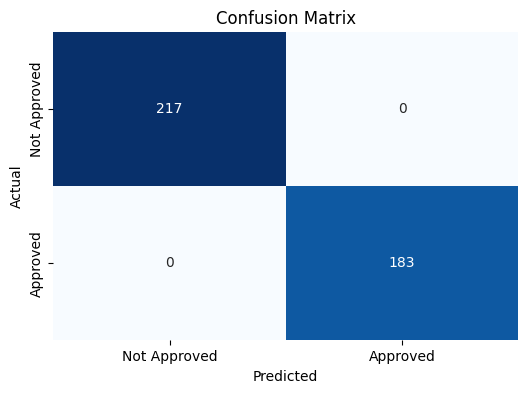

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Create and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
xticklabels=['Not Approved', 'Approved'], yticklabels=['Not Approved', 'Approved'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

While these results (100% Accuracy, Precision, Recall, and F1-Score) appear excellent, such perfect scores on a real-world dataset, especially one like loan approval, are highly suspicious. This strongly suggests either:

Overfitting: The model has memorized the training data, including any noise, and is not generalizing well to unseen data (though the test set was 'unseen' by the model, there might be underlying issues in data preparation or splitting).
Data Leakage: Information from the target variable (loan_approved) might have inadvertently seeped into the features (X) during data preprocessing or feature engineering. This allows the model to 'cheat' by having access to the answer during training or prediction.
It is crucial to re-examine the entire data preparation pipeline, from feature engineering to the train-test split, to identify and rectify any potential data leakage or overfitting sources. A model with perfect scores in a real-world scenario is almost always indicative of a methodological error rather than true perfect performance.

Q10. Model Evaluation – ROC Curve & AUC
a) Plot the ROC curve.
b) Calculate the AUC score.

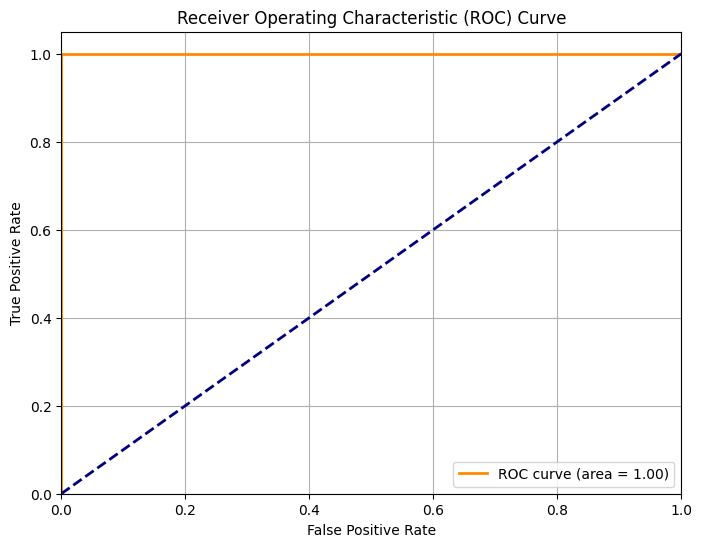

AUC Score: 1.0000


In [17]:
# Model Evaluation – ROC Curve & AUC a) Plot the ROC curve.

from sklearn.metrics import roc_curve, auc

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test_scaled)[:, 1])
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# b) Calculate the AUC score.
print(f"AUC Score: {roc_auc:.4f}")

